In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2,os,glob
import numpy as np
from tqdm import tqdm
from scipy import stats as ks_stats
import seaborn as sns
import numpy as np
from numpy.linalg import norm
from scipy.stats import pearsonr, spearmanr, ks_2samp
from scipy import stats
from FreeAeonML.FACommon import CFACommon
from FreeAeonML.FADataEDA import CFADataDistribution,CFADataTest,CFAFitter,CFACommonStats

# Common Functions

In [2]:
def get_files(directory):
    png_files = glob.glob(f"{directory}/*.csv")
    png_files_recursive = glob.glob(f"{directory}/**/*.csv", recursive=True)
    return png_files_recursive

def load_sample(action):
    fake_folder = get_files(f"../data/face/features/train/fake/")
    real_folder = get_files(f"../data/face/features/train/real/")
    result = []
    for file in tqdm(fake_folder,desc=f"loading {action}"):
        tmp = file.split(".csv")[0].split("/")[-1].split("-")
        pca = int(tmp[0])
        file_id = tmp[1]
        type = tmp[2]
        if type != action:
            continue
        if pca > 32:
            continue
        df_tmp = pd.read_csv(file)
        df_tmp['kind'] = "fake"
        df_tmp['pca'] = pca
        df_tmp['file'] = file_id
        result.append(df_tmp)

    for file in tqdm(real_folder,desc = f"loading {action}"):
        tmp = file.split(".csv")[0].split("/")[-1].split("-")
        pca = int(tmp[0])
        file_id = tmp[1]
        type = tmp[2]
        if type != action:
            continue
        if pca > 32:
            continue
        df_tmp = pd.read_csv(file)
        df_tmp['kind'] = "real"
        df_tmp['pca'] = pca
        df_tmp['file'] = file_id
        result.append(df_tmp)

    return pd.concat(result,ignore_index=True).reset_index(drop = True)

def normality_check(data):
    result = {}
    s = pd.Series(data)
    result['skew'] = s.skew()
    result['kurt'] = s.kurt()
    d_stat, p_value = ks_stats.kstest((data - np.mean(data)) / np.std(data), 'norm')
    
    result['ks_value'] = d_stat
    result['p_value'] = p_value
    
    if abs(result['skew']) < 0.5 and abs(result['kurt']) < 1.0 and result['ks_value'] < 0.03:
        result['normality'] = "Strong"
    elif abs(result['skew']) < 1.0 and abs(result['kurt']) < 2.0:
        result['normality'] = "Approximate"
    else:
        result['normality'] = "Deviation"
    return result

def remove_outliers_zscore(data, threshold=3.0):
    z = np.abs(stats.zscore(data, nan_policy='omit'))
    return data[z <= threshold]

def distribution_similarity_check(ds_real, ds_fake):
    result = {}
    ds_fake = remove_outliers_zscore(np.array(ds_fake), threshold=3.0)
    ds_real = remove_outliers_zscore(np.array(ds_real), threshold=3.0)
    d_stat, p_value = ks_stats.kstest(ds_real, ds_fake)
    #d_stat, p_value = ks_stats.ks_2samp(ds_real, ds_fake, alternative='two-sided', mode='auto')
    result['d_stat'] = d_stat
    result['p_value'] = p_value
    if d_stat < 0.02:
        result['similarity'] = "Identical"     
    elif d_stat < 0.05:
        result['similarity'] = "Very Similar"  
    elif d_stat < 0.10:
        result['similarity'] = "Fairly Similar" 
    elif d_stat < 0.20:
        result['similarity'] = "Marginal"     
    else:
        result['similarity'] = "Dissimilar"   
    return result

# Samples

## face images

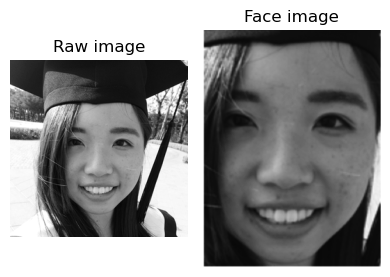

In [3]:
face_id = 10
raw_path = f"../data/raw/dataset/flickrfaceshq-dataset-ffhq/{face_id}.png"
face_path = f"../data/face/crop/real/{face_id}.png"
fig, axes = plt.subplots(1, 2, figsize=(4, 4))
raw_img = cv2.imread(raw_path, cv2.IMREAD_GRAYSCALE)
face_img = cv2.imread(face_path, cv2.IMREAD_GRAYSCALE)
axes[0].imshow(raw_img, cmap='gray') 
axes[0].set_title(f"Raw image", fontsize=12)
axes[0].axis('off')
axes[1].imshow(face_img, cmap='gray') 
axes[1].set_title(f"Face image", fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Raw Image with PCA

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 204.93it/s]


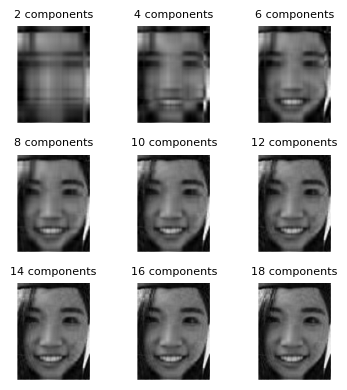

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(4, 4))
axes = axes.flatten()
for i in tqdm(range(0,len(axes))): 
    img_path = f"../data/face/features/train/real/{(i+1)*2}-{face_id}.png"
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(image, cmap='gray') 
    axes[i].set_title(f"{(i+1)*2} components", fontsize=8)
    axes[i].axis('off')
    i = i + 1

plt.tight_layout()
plt.show()

## Residual Images with PCA

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 214.39it/s]


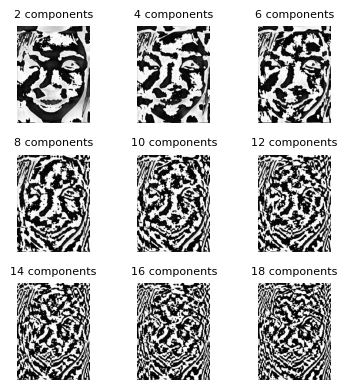

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(4, 4))
axes = axes.flatten()
for i in tqdm(range(0,len(axes))): 
    img_path = f"../data/face/features/train/real/{(i+1)*2}-{face_id}.png"
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    residual = face_img - image
    axes[i].imshow(residual, cmap='gray') 
    axes[i].set_title(f"{(i+1)*2} components", fontsize=8)
    axes[i].axis('off')
    i = i + 1
plt.tight_layout()
plt.show()

# Common

In [6]:
df_stats = CFACommon.load_csv("../data/face/stats/train/common.csv")

Loading data ../data/face/stats/train/common.csv: 100%|█████████████████████████████████████████▉| 46080/46080.001 [00:47<00:00, 966.90it/s]


In [7]:
df_stats.keys()

Index(['mean', 'skew', 'kurt_fisher', 'kurt_pearson', 'autocorr_lag1', 'range',
       'min', 'max', 'iqr', 'std', 'cv', 'item', 'kind', 'pca'],
      dtype='object')

## KS test

In [8]:
data_list = []
for pca,df_t in tqdm(df_stats.groupby('pca')): 
    for key in ['fd','entropy','mean','skew','kurt','std']:
        for item in ['mean','std']:
            df_tmp = df_t.copy(deep = True)
            df_tmp = df_tmp[df_tmp['item'] == key].reset_index(drop = True)
            ds_real = df_tmp[df_tmp['kind'] == 'real'][item].reset_index(drop = True)
            ds_fake = df_tmp[df_tmp['kind'] == 'fake'][item].reset_index(drop = True)
            real = normality_check(ds_real)
            fake = normality_check(ds_fake)
            d_stat = distribution_similarity_check(ds_real, ds_fake)
            tmp = {}
            tmp['pca'] = pca
            tmp['key'] = key
            tmp['item'] = item
            tmp['real_normal_ks'] = real['ks_value']
            tmp['real_normal_ks_p_value'] = real['p_value']
            tmp['real_normal_skew'] = real['skew']
            tmp['real_normal_kurt'] = real['kurt']
            tmp['real_normality'] = real['normality']

            tmp['fake_normal_ks'] = fake['ks_value']
            tmp['fake_normal_ks_p_value'] = fake['p_value']
            tmp['fake_normal_skew'] = fake['skew']
            tmp['fake_normal_kurt'] = fake['kurt']
            tmp['fake_normality'] = fake['normality']
            
            tmp['real_fake_ks'] = d_stat['d_stat']
            tmp['real_fake_ks_p_value'] = d_stat['p_value']
            
            data_list.append(tmp)
            
df_common_similar = pd.DataFrame(data_list)
df_common_similar.to_csv("../data/face/stats/train/common_similar.csv",index=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:52<00:00,  2.43it/s]


In [9]:
df_common_similar = pd.read_csv("../data/face/stats/train/common_similar.csv")
df_common_similar.keys()

Index(['pca', 'key', 'item', 'real_normal_ks', 'real_normal_ks_p_value',
       'real_normal_skew', 'real_normal_kurt', 'real_normality',
       'fake_normal_ks', 'fake_normal_ks_p_value', 'fake_normal_skew',
       'fake_normal_kurt', 'fake_normality', 'real_fake_ks',
       'real_fake_ks_p_value'],
      dtype='object')

## Overview KS between Real and Fake
- by common features' distribution 

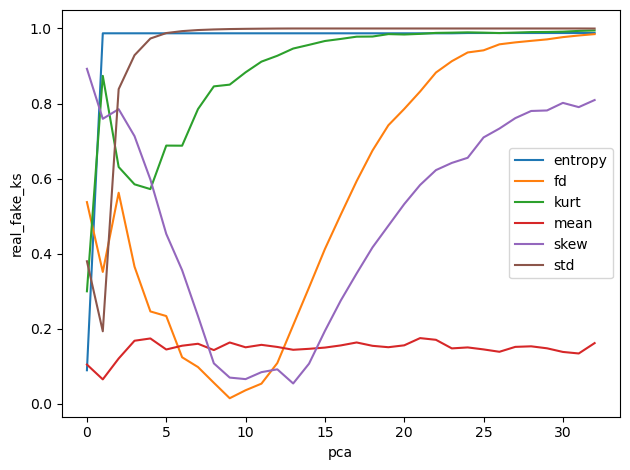

In [10]:
for key,df_tmp in df_common_similar[df_common_similar['pca'] <=32].groupby("key"):
    df_tmp = df_tmp[df_tmp['item'] == 'mean']
    sns.lineplot(data=df_tmp,x='pca',y='real_fake_ks',label=key)
plt.tight_layout()
plt.show()

## Base line (before PCA)

### common feature distribution

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 14.40it/s]


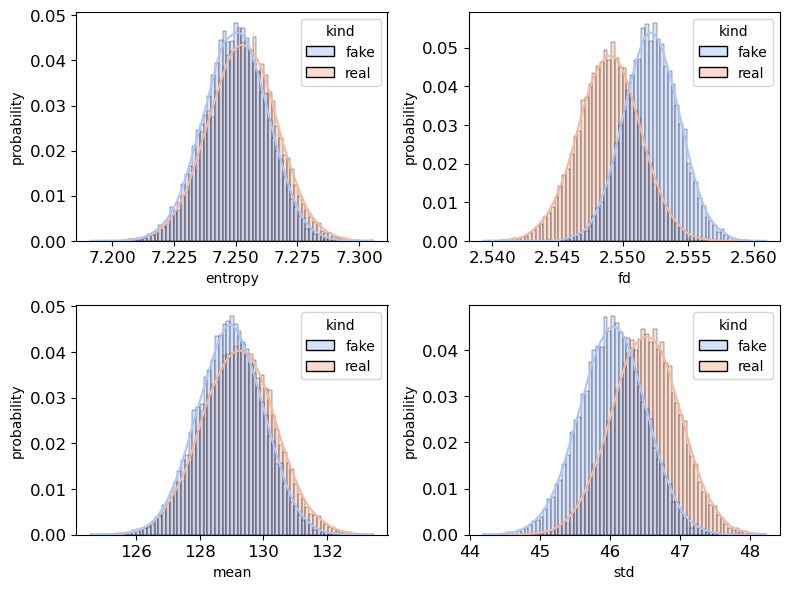

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
measuer_list = ['fd','entropy','std','mean']
i = 0
for item,df_tmp in tqdm(df_stats[df_stats['pca']==0].groupby('item')): 
    if i >= len(axes):
        break
    if not item in measuer_list:
        continue
    sns.histplot(data=df_tmp,x='mean',hue='kind',bins=75,stat="probability",
                 common_norm=False,palette='coolwarm',kde=True,
                 kde_kws={'bw_adjust': 1.5},
                 ax=axes[i])
    #axes[i].set_title(f"{item}",fontsize=12)
    axes[i].tick_params(axis='x', labelsize=12)
    axes[i].tick_params(axis='y', labelsize=12)
    axes[i].set_xlabel(item) 
    axes[i].set_ylabel("probability")
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('upper right')   
    i = i + 1
    
plt.tight_layout()
plt.show()

### KS test result

In [12]:
df_tmp = df_common_similar[df_common_similar['pca'] == 0]
df_tmp = df_tmp[df_tmp['key'].isin(measuer_list)]
df_tmp = df_tmp[df_tmp['item'] == 'mean']
df_tmp = df_tmp.drop(columns=['pca'])
df_tmp

,key,item,real_normal_ks,real_normal_ks_p_value,real_normal_skew,real_normal_kurt,real_normality,fake_normal_ks,fake_normal_ks_p_value,fake_normal_skew,fake_normal_kurt,fake_normality,real_fake_ks,real_fake_ks_p_value
0,fd,mean,0.004371,0.837706,-0.023966,0.015651,Strong,0.003700,0.946161,-0.003282,0.037597,Strong,0.537356,0.000000e+00
2,entropy,mean,0.005248,0.638335,-0.040458,0.036984,Strong,0.004563,0.797457,-0.025621,-0.037075,Strong,0.089238,1.507969e-69
4,mean,mean,0.004933,0.713254,-0.034830,0.004551,Strong,0.004137,0.881943,-0.000218,-0.024372,Strong,0.104401,4.225388e-95
10,std,mean,0.005448,0.590825,-0.030754,-0.020147,Strong,0.004037,0.899020,-0.008404,0.025494,Strong,0.379718,0.000000e+00


## Residual (After PCA)

### feature distribution

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.46s/it]


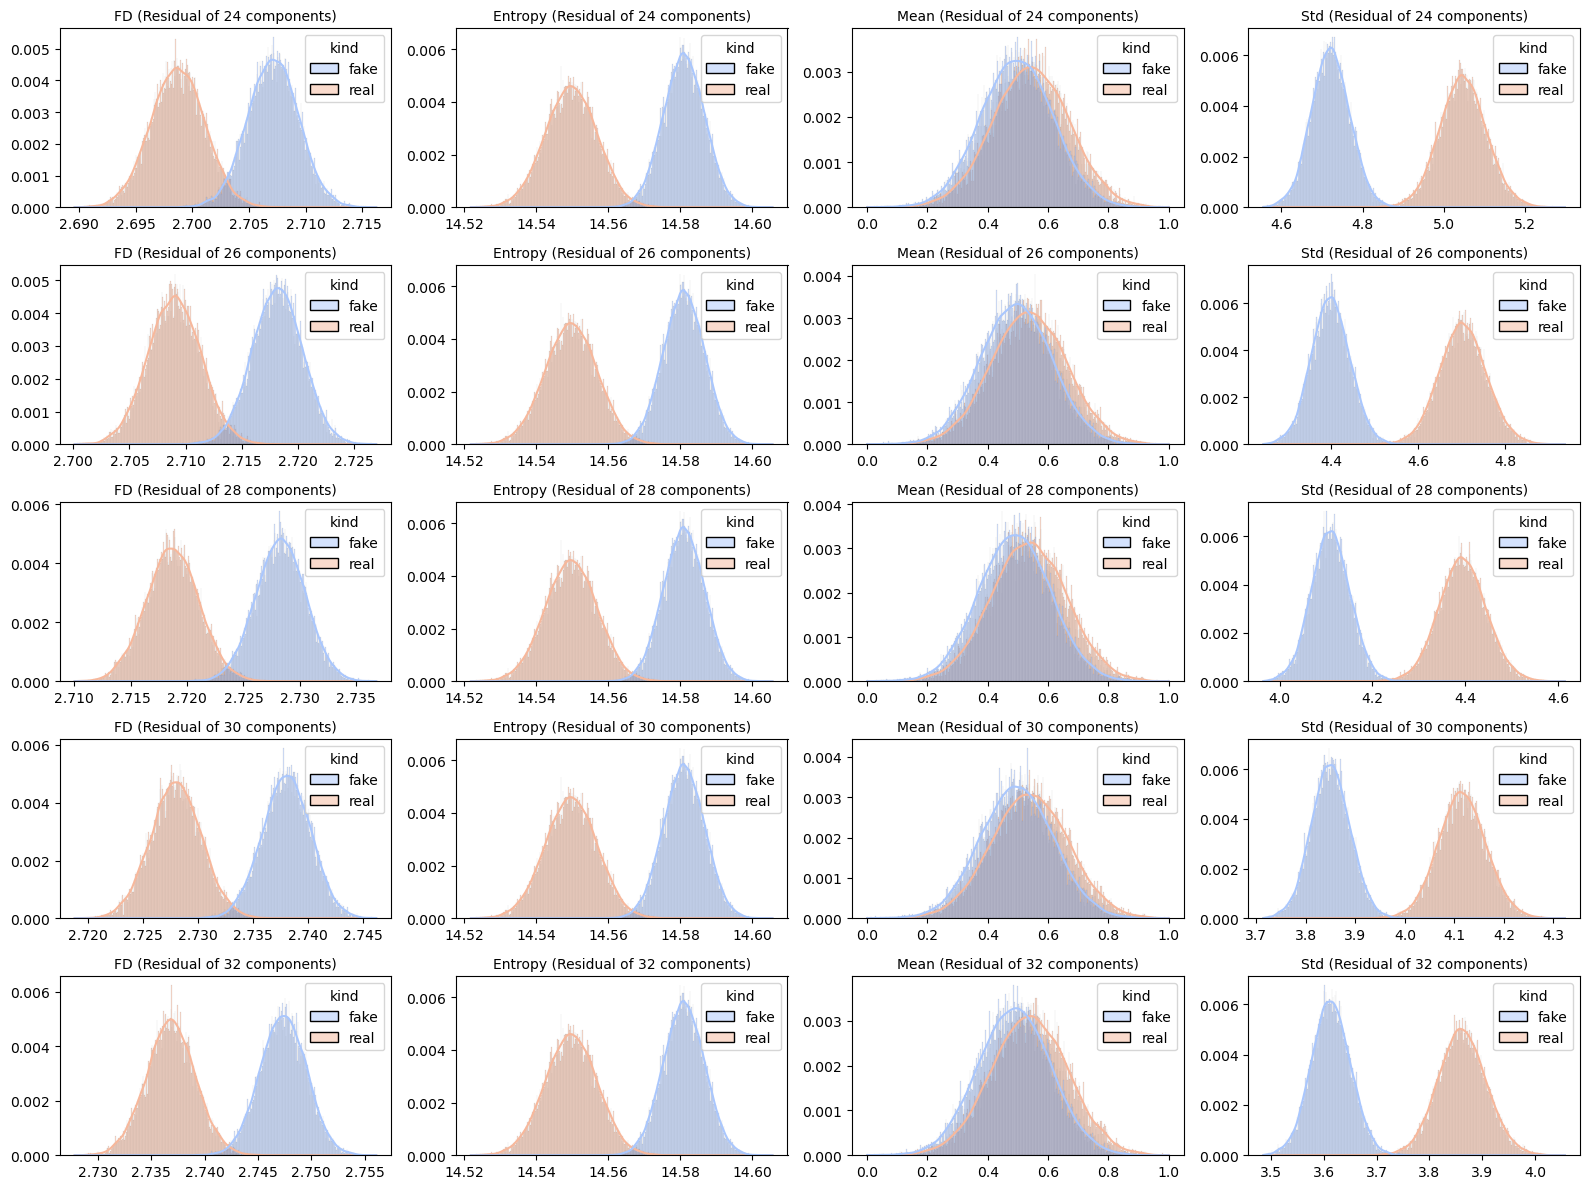

In [13]:
df_data = df_stats[df_stats['pca'].isin([24,26,28,30,32])].reset_index(drop = True)
fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()
i = 0
for pca,df_tmp in tqdm(df_data.groupby('pca')): 
    if i >= len(axes):
        break
    df_t = df_tmp[df_tmp['item'] == 'fd'].reset_index(drop = True)
    sns.histplot(data=df_t,x='mean',hue='kind',bins=500,stat="probability",
                 common_norm=True,palette='coolwarm',kde=True,ax=axes[i])
    axes[i].set_title(f"FD (Residual of {pca} components)",fontsize=10)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("") 
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('upper right')     
    i = i + 1

    df_t = df_tmp[df_tmp['item'] == 'entropy'].reset_index(drop = True)
    sns.histplot(data=df_t,x='mean',hue='kind',bins=500,stat="probability",
                 common_norm=True,palette='coolwarm',kde=True,ax=axes[i])
    axes[i].set_title(f"Entropy (Residual of {pca} components)",fontsize=10)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("")
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('upper right')   
    i = i + 1

    df_t = df_tmp[df_tmp['item'] == 'mean'].reset_index(drop = True)
    df_t['mean'] =  (df_t['mean'] -  df_t['mean'].min()) / (df_t['mean'].max() -  df_t['mean'].min())
    sns.histplot(data=df_t,x='mean',hue='kind',bins=500,stat="probability",
                 common_norm=True,palette='coolwarm',kde=True,ax=axes[i])
    axes[i].set_title(f"Mean (Residual of {pca} components)",fontsize=10)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)
    axes[i].ticklabel_format(style='plain', axis='x')
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("")
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('upper right')   
    i = i + 1

    df_t = df_tmp[df_tmp['item'] == 'std'].reset_index(drop = True)
    sns.histplot(data=df_t,x='mean',hue='kind',bins=500,stat="probability",
                 common_norm=True,palette='coolwarm',kde=True,ax=axes[i])
    axes[i].set_title(f"Std (Residual of {pca} components)",fontsize=10)
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("") 
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('upper right')   
    i = i + 1
    
plt.tight_layout()
plt.show()

### KS test result

In [14]:
pd.set_option('display.float_format', '{:.4f}'.format)  # 6 位小数，可按需调整
#pd.set_option('display.float_format', '{:.3e}'.format)  # 按需要调整有效位数
df_tmp = df_common_similar[df_common_similar['key'].isin(measuer_list)]
df_tmp = df_tmp[df_tmp['item'] == 'mean']
df_tmp = df_tmp[df_tmp['pca'].isin([24,26,28,30,32])].reset_index(drop = True)
df_tmp[['pca','key','real_fake_ks','real_fake_ks_p_value']]

,pca,key,real_fake_ks,real_fake_ks_p_value
0,24,fd,0.9361,0.0000
1,24,entropy,0.9879,0.0000
2,24,mean,0.1501,0.0000
3,24,std,1.0000,0.0000
4,26,fd,0.9578,0.0000
5,26,entropy,0.9879,0.0000
6,26,mean,0.1385,0.0000
7,26,std,1.0000,0.0000
8,28,fd,0.9671,0.0000
9,28,entropy,0.9879,0.0000


# MFS

In [3]:
df_mfs = load_sample("mfs")

loading mfs: 100%|█████████████████████████████████████████████████████████████████████████████| 2404608/2404608 [03:51<00:00, 10407.77it/s]


## MFS of raw images (before PCA)

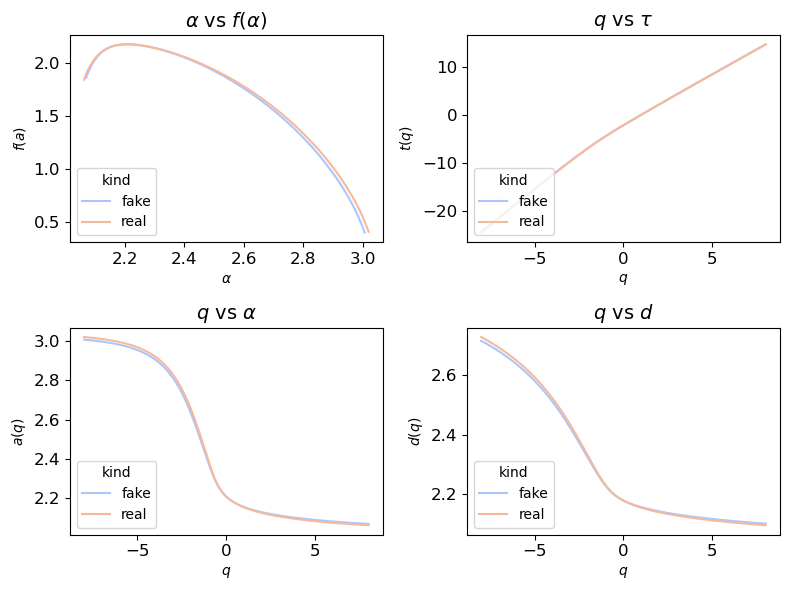

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
df_tmp = df_mfs[df_mfs['pca'] == 0]
df_tmp = df_tmp.groupby(['kind','q']).mean(numeric_only=True).reset_index()

plots = [        
    ('a(q)', 'f(a)', "$\\alpha$ vs $f(\\alpha)$"),
    ('q', 't(q)', "$q$ vs $\\tau$"),
    ('q', 'a(q)', "$q$ vs $\\alpha$"),
    ('q', 'd(q)', "$q$ vs $d$")
]

for i, (x, y, title) in enumerate(plots):
    #df_tmp[x] = df_tmp[x].round(3)    
    #df_tmp[y] = df_tmp[y].round(3)
    sns.lineplot(
        data=df_tmp, x=x, y=y, hue="kind",
        palette='coolwarm',  
        ax=axes[i]
    )
    axes[i].set_title(f"{title}",fontsize=14)
    if x == 'a(q)':
        x = '\\alpha'
    axes[i].set_xlabel(f"${x}$") 
    axes[i].set_ylabel(f"${y}$") 
    axes[i].tick_params(axis='x', labelsize=12)
    axes[i].tick_params(axis='y', labelsize=12)
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('lower left') 
plt.tight_layout()

## MFS of Residual images (after PCA)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [00:04<00:00,  7.61it/s]


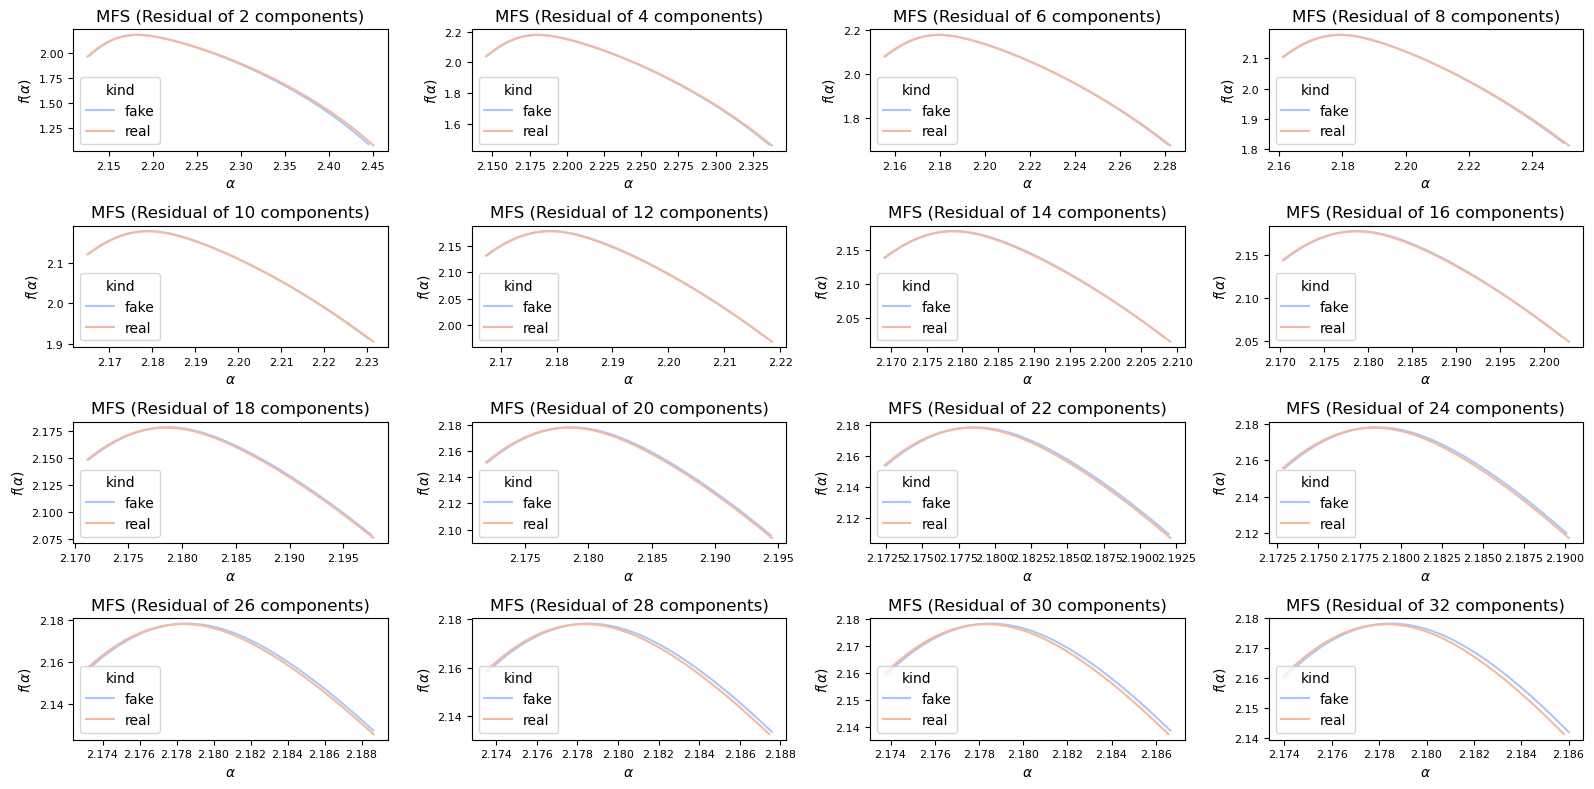

In [6]:
fig, axes = plt.subplots(4,4, figsize=(16, 8))
axes = axes.flatten()
i = 0
pca_list = [24,26,28,30,32]
for pca,df_tmp in tqdm(df_mfs.groupby("pca")):
    if pca == 0:
        continue
    if pca % 2 != 0:
        continue
    df_tmp = df_tmp.groupby(['kind','q']).mean(numeric_only=True)
    #df_tmp['a(q)'] = df_tmp['a(q)'].round(4)
    sns.lineplot(data=df_tmp, x='a(q)', y='f(a)', hue='kind',
                 palette='coolwarm',  
                 ax=axes[i])
    axes[i].set_title(f"MFS (Residual of {pca} components)")
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].set_xlabel("$\\alpha$") 
    axes[i].set_ylabel("$f(\\alpha)$") 
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('lower left') 
    i = i + 1
plt.tight_layout()
plt.show()

## KS test

In [7]:
all_data = []
for item,df_tmp in tqdm(df_mfs.groupby(['pca','q'])):
    pca,q = item[0],item[1]
    df_real = df_tmp[df_tmp['kind'] == 'real'].reset_index(drop = True)
    df_fake = df_tmp[df_tmp['kind'] == 'fake'].reset_index(drop = True)
    ks_a = distribution_similarity_check(df_real['a(q)'],df_fake['a(q)'])
    ks_d = distribution_similarity_check(df_real['d(q)'],df_fake['d(q)'])
    ks_fa = distribution_similarity_check(df_real['f(a)'],df_fake['f(a)'])

    tmp = {}
    tmp['pca'] = pca
    tmp['q'] = q
    tmp['a'] = ks_a['d_stat']
    tmp['a_p'] = ks_a['p_value']
    tmp['d'] = ks_d['d_stat']
    tmp['d_p'] = ks_d['p_value']
    tmp['f(a)'] = ks_fa['d_stat']
    tmp['f(a)_p'] = ks_fa['p_value']
    all_data.append(tmp)
df_mfs_similar = pd.DataFrame(all_data)
df_mfs_similar.to_csv("../data/face/stats/train/mfs_similar.csv",index=False)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 4257/4257 [05:27<00:00, 13.00it/s]


In [8]:
df_mfs_similar = pd.read_csv("../data/face/stats/train/mfs_similar.csv")

## heatmap for KS test by q and PCA components

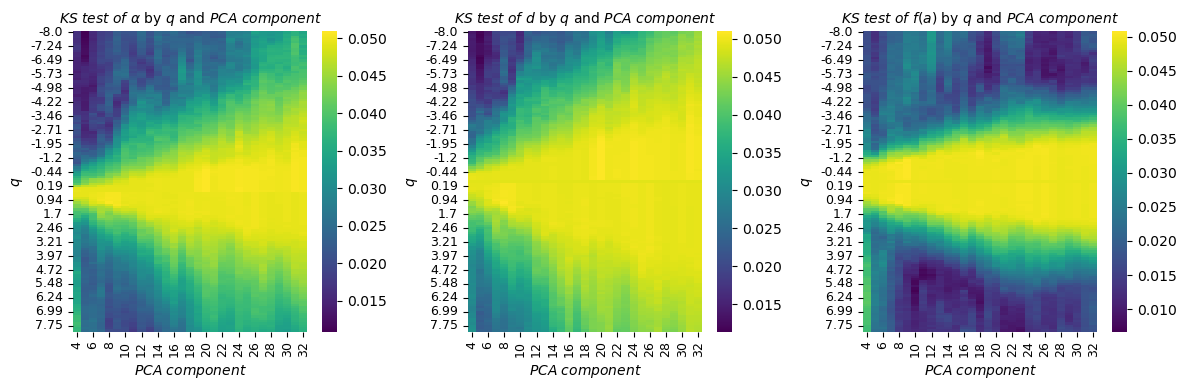

In [9]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))
axes = axes.flatten()
i = 0
df_tmp = df_mfs_similar.sort_values(['q', 'pca'])
for measure in ['a','d','f(a)']:
    df_tmp = df_tmp[df_tmp['pca'] > 3]
    df_tmp['q'] = df_tmp['q'].round(2)
    heat_data = df_tmp.pivot(index='q', columns='pca', values=measure)
    sns.heatmap(heat_data,cmap='viridis', ax=axes[i])
    if measure == 'a':
        measure = "\\alpha"
    axes[i].set_title(f"$KS$ $test$ $of$ ${measure}$ by $q$ and $PCA$ $component$",fontsize=10)
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].set_ylabel("$q$") 
    axes[i].set_xlabel("$PCA$ $component$") 
    i = i + 1
plt.tight_layout()
plt.show()

## KS test result by MFS features and PCA components

<Axes: xlabel='pca', ylabel='a'>

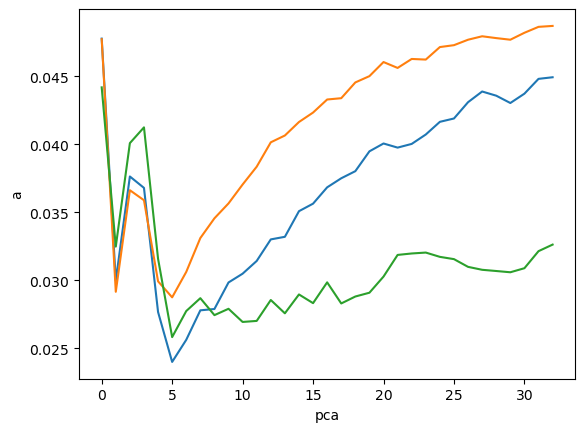

In [10]:
df_tmp = df_mfs_similar.groupby(['pca','q']).mean(numeric_only=True)
df_tmp = df_mfs_similar.groupby(['pca']).mean(numeric_only=True)
sns.lineplot(data=df_tmp,x='pca',y='a')
sns.lineplot(data=df_tmp,x='pca',y='d')
sns.lineplot(data=df_tmp,x='pca',y='f(a)')

## LAC

In [4]:
df_lac = load_sample("lac")

loading lac: 100%|█████████████████████████████████████████████████████████████████████████████| 2404608/2404608 [03:22<00:00, 11866.56it/s]


## lacunarity by scales (before PCA)

Text(0.5, 1.0, 'Lacunarity of Raw images')

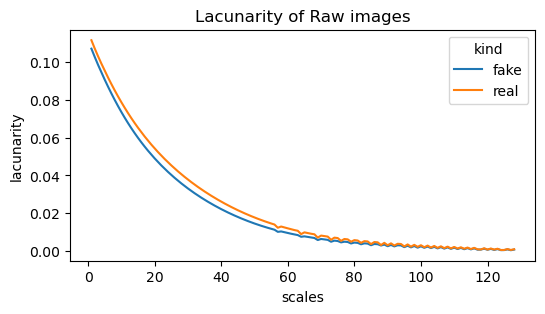

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(6, 3))
df_tmp = df_lac[df_lac['pca'] == 0].reset_index(drop = True)
df_tmp['lacunarity'] = (df_tmp['lacunarity'] - df_tmp['lacunarity'].min()) / (df_tmp['lacunarity'].max() - df_tmp['lacunarity'].min())
#df_tmp['lacunarity'] = (df_tmp['lacunarity'] - df_tmp['lacunarity'].mean()) /df_tmp['lacunarity'].std()
df_tmp = df_tmp.groupby(['kind','scales']).mean(numeric_only=True).reset_index()
sns.lineplot(data=df_tmp,x='scales',y='lacunarity',hue='kind', ax=axes)
axes.set_title(f"Lacunarity of Raw images")


## lacunarity by scales (after PCA)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [00:03<00:00,  9.70it/s]


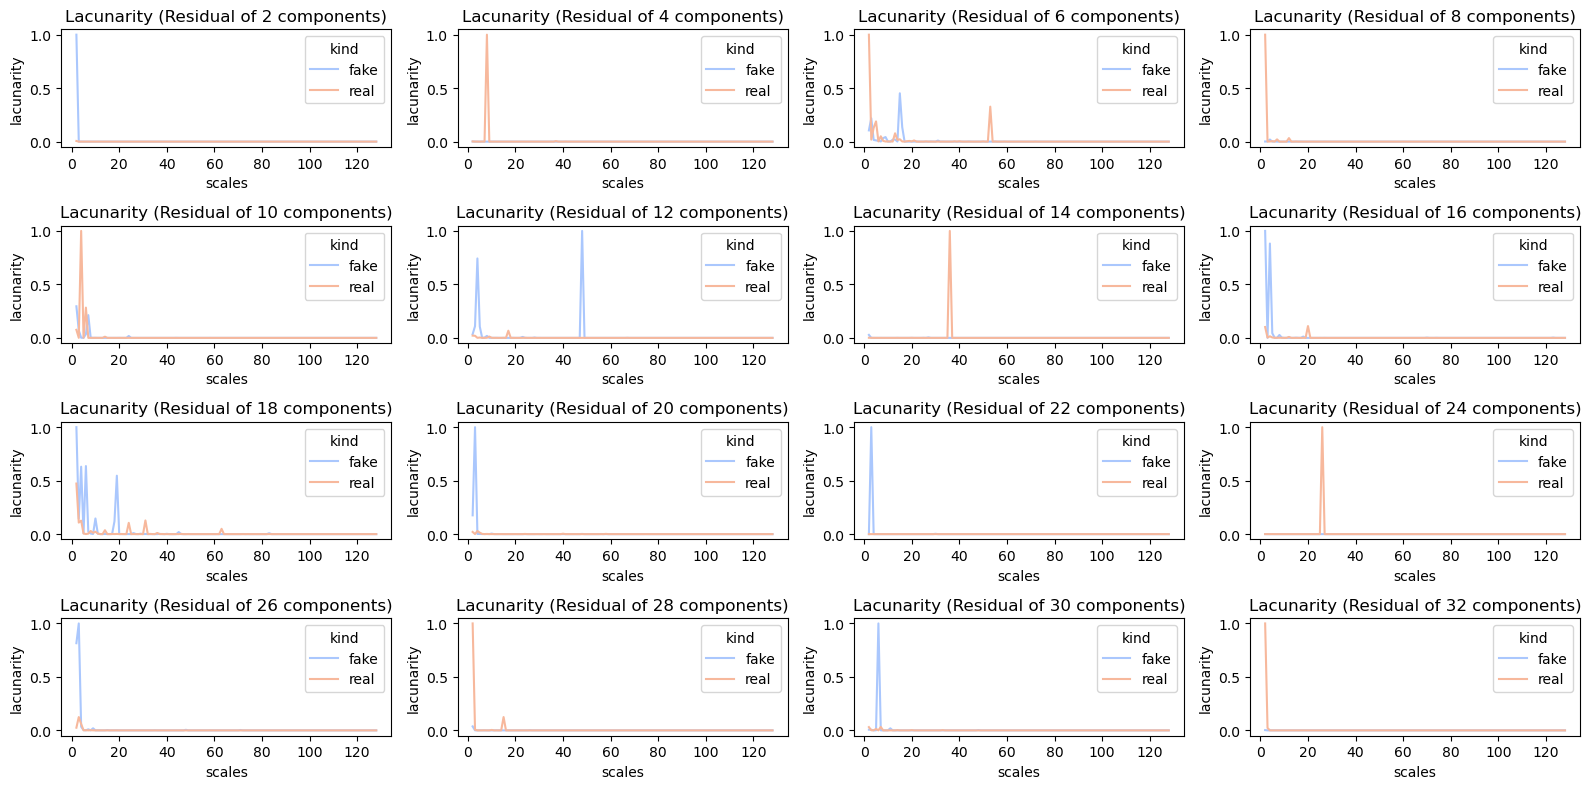

In [6]:
fig, axes = plt.subplots(4,4, figsize=(16, 8))
axes = axes.flatten()
i = 0
df_data = df_lac[df_lac['pca'] <= 32]
for pca,df_tmp in tqdm(df_data.groupby("pca")):
    if pca == 0:
        continue
    if pca % 2 != 0:
        continue    
    df_tmp = df_tmp.groupby(['kind','scales']).mean(numeric_only=True).reset_index()
    df_tmp['lacunarity'] = (df_tmp['lacunarity'] - df_tmp['lacunarity'].min()) / (df_tmp['lacunarity'].max() - df_tmp['lacunarity'].min())
    #df_tmp['lacunarity'] = (df_tmp['lacunarity'] - df_tmp['lacunarity'].mean()) /df_tmp['lacunarity'].std()
    sns.lineplot(data=df_tmp, x='scales', y='lacunarity', hue='kind',
                 palette='coolwarm',  
                 ax=axes[i])
    axes[i].set_title(f"Lacunarity (Residual of {pca} components)")
    axes[i].tick_params(axis='x', labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)
    axes[i].set_xlabel("scales") 
    axes[i].set_ylabel("lacunarity") 
    legend = axes[i].get_legend()
    if legend is not None:
        legend.set_title('kind')       
        legend.set_loc('upper right') 
    i = i + 1
plt.tight_layout()
plt.show()